# Air resistance with trajectories

# Problem:  
A regulation baseball is about 74 mm in diameter, with a weight of 145 g.  It is thrown with a velocity of 140 km/hour at an angle of 45$^o$ above the ground.  Calculate the trajectory and compare it to the trajectory without air resistance.  Assume the atmospheric pressure is typical of Edmonton, with 92.6 kPa.  What is the distance between the case with and without air resistance?  What fraction of its energy is expended in work against air resistance?  

## Physics:

The drag force (or air resistance) is usually given by the expression
$$\vec{F_D}=-C_D A\frac{\rho v^2}{2}\hat{v}$$
where $C_D$ is called the drag coefficient and $A$ is the cross sectional area of an object.  This makes physical sense just based on Bernouilli's equation, which generates a pressure $1/2\rho v^2,$ and a force is pressure x area.  The drag coefficient is normally tabulated in terms of Reynolds number: 

\begin{equation}
R=\frac{\rho vl}{\eta}
\end{equation}

Here $\rho$ is the density of air.  Just to be careful we work it out for an average Edmonton day- where our atmospheric pressure is 92.6 kPa compared to the standard atmosphere with pressure 101.325 kPa and density 1.225 kg/m3

l=Diameter=2*radius

We can now calculate the acceleration:
$$\vec{a}=\frac{\vec{F}}{m}=\vec{g}-C_D A\frac{\rho v^2}{2m}\hat{v}$$
and solve the ode.

Using the definition of work: $W=\int \vec{F}\cdot \vec{dx}=\int \vec{F}_D\cdot \vec{v} dt$ we can calculate the work done against air resistance.



## Numerics
We solve the ODE using solve_ivp, breaking the equation up into 2 components:

$$\frac{d}{dt} \left( \begin{array}{c} \vec{v} \\ \vec{x} \end{array} \right) =
\left( \begin{array}{c} \vec{g} -C_D A\frac{\rho v^2}{2m}\hat{v} \\ \vec{v} \end{array} \right)$$

which corresponds to six equations.  

We repeat with $C_D =0$ to get the trajectory without air resistance.  

We will need to interpolate our table of drag coefficients; since it is in tabular form we will use interp1d cubic interpolation.  

We will need to use dense output to use scipy.optimize.root to calculate where the ball hits the ground.

## Validation

To validate we look at the energy:
$$E(t)=\rm{constant}=\frac{mv^2}{2}+mgh+\vec{F_D}\cdot \vec{v} dt'$$
which should be a constant.

It is easy to find the kinetic+ potential energy from the integrated trajectory.

To this we need to add the work done against air resistance.  We take the derivative of the air resistance term :
$$\frac{dE_D}{dt}=\vec{F_D}\cdot \vec{v}$$

We add this as a third component of our ODE:
$$\frac{d}{dt} \left( \begin{array}{c} \vec{v} \\ \vec{x}\\ E_D \end{array} \right) =
\left( \begin{array}{c} \vec{g} -C_D A\frac{\rho v^2}{2m}\hat{v} \\ \vec{v} \\ \vec{F_D}\cdot \vec{v}\end{array} \right)$$

At the end of the calculation, we will add the work against air to the final kinetic+potential energy and compare it to the initial energy of the ball.  



In [1]:
import numpy as np
import matplotlib.pyplot as plt

airPressure=92.6 #kPa
#airPressure=101.325
standardAirDensity=1.225 # kg/m**3
standardAirPressure=101.325 #kPa
airDensity=airPressure/standardAirPressure*standardAirDensity
airViscosity=1.827e-5   #Pa-s  
radius=74e-3/2 #m
mass=0.145 #kg

def ReynoldsNumber(velocity):
    '''Calculates Reynolds number. Because it is used 
    in an logarithmic interpolation, we impose 1 as a lower cutoff'''
    R=airDensity*velocity*radius*2/airViscosity
    return np.maximum(R,1)

v=140000/3600.0 #m/s
print(f'Reynolds Number at velocity {v:6.2f} m/s= {ReynoldsNumber(v):7.0f}')

Reynolds Number at velocity  38.89 m/s=  176339


Many fluid mechanics books give a plot of drag of a sphere as a function of Reynold's number.  I include such a plot below (from Munson, B. R., Young, D. F., and Okiishi, T. H., Fundamentals of Fluid Mechanics, Wiley, NY, 1990)
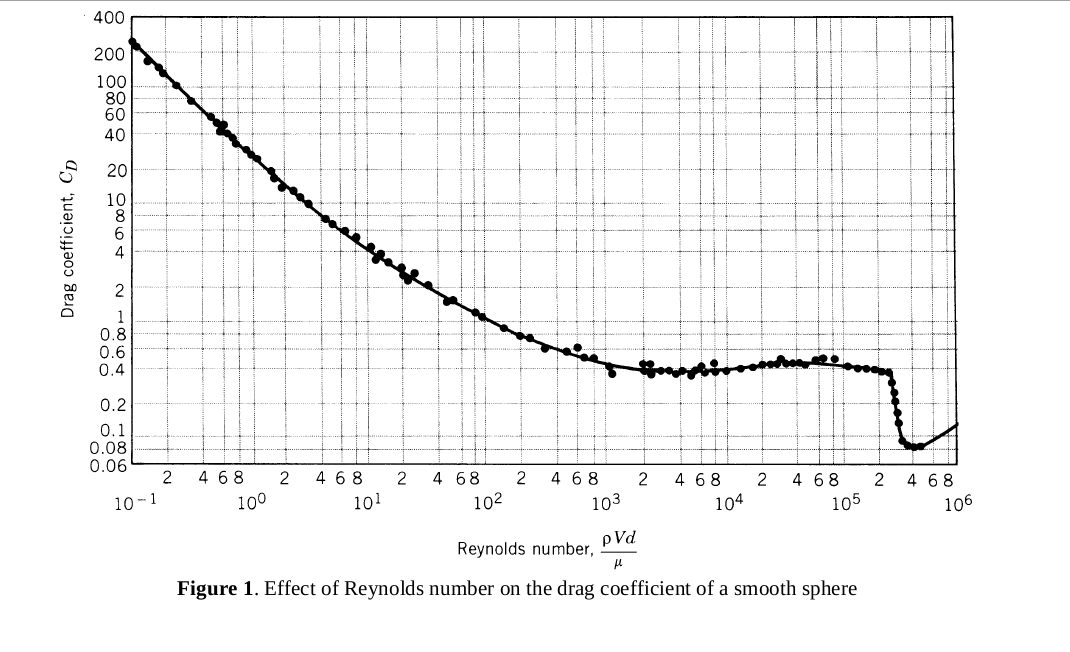

The part of this curve that is relevant is less than 400000.  There is no easy functional form, and so we are going to need to interpolate.  

We read off several points (this is easier than any other way to get the data)

|Reynolds Number|Drag Coefficient|
|---------------|----------------|
|1|24|
|4|8|
|10|4|
|40|1.7|
|100|1.1|
|400|0.6|
|1000|0.45|
|2000|0.4|
|4000|0.35|
|10000| 0.40|
|20000| 0.45|
|40000| 0.46|
|100000| 0.42|
|200000| 0.39|
|400000| 0.08|


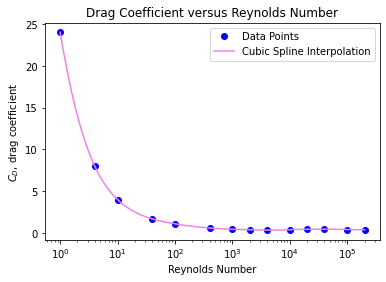

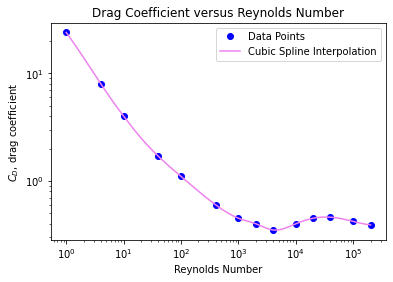

In [3]:
RN=np.array([1,4,10,40,100,400,1000,2000,4000,10000,20000,40000,100000,200000]) # leave out 400000 since it will add wiggles
DC=np.array([24,8,4,1.7,1.1,0.6,0.45,0.4,0.35,0.40,0.45,0.46,0.42,0.39])
import scipy.interpolate
logRN=np.log(RN)  #interpolation in log ReynoldsNumber will be more sensible
plotX=np.logspace(np.log10(RN[0]),np.log10(RN[-1]),100)
splineInterpolation=scipy.interpolate.interp1d(logRN,DC,kind='cubic')
def DragCoefficient(reynoldsNumber):
    return splineInterpolation(np.log(reynoldsNumber))

plt.title("Drag Coefficient versus Reynolds Number")
plt.ylabel(r'$C_D$, drag coefficient')
plt.xlabel("Reynolds Number")
plt.semilogx(RN,DC,'o',color='blue',label='Data Points')
plt.plot(plotX,DragCoefficient(plotX),color='violet',label="Cubic Spline Interpolation")
plt.legend();
plt.show()

plt.title("Drag Coefficient versus Reynolds Number")
plt.ylabel(r'$C_D$, drag coefficient')
plt.xlabel("Reynolds Number")
plt.loglog(RN,DC,'o',color='blue',label='Data Points')
plt.plot(plotX,DragCoefficient(plotX),color='violet',label="Cubic Spline Interpolation")
plt.legend();
plt.show()



In [4]:
def FDrag(v):
    #takes as input the vector v and returns a vector drag force
    velocity=np.linalg.norm(v)
    Cd=DragCoefficient(ReynoldsNumber(velocity))
    return -0.5*airDensity*Cd*velocity*v*np.pi*radius**2 #normally, we think velocity**2, but use 1 power to make velocity unit vector

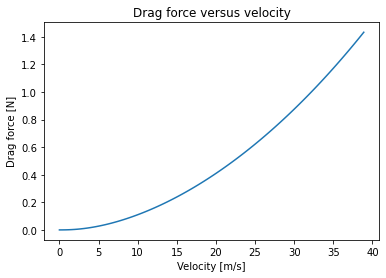

In [5]:
vlist=np.linspace(0,140e3/3600,100)
drag=np.array([np.linalg.norm(FDrag(np.array([0,0,v]))) for v in vlist])
plt.plot(vlist,drag)
plt.title("Drag force versus velocity")
plt.xlabel("Velocity [m/s]")
plt.ylabel("Drag force [N]")
plt.show()

In [17]:
from scipy.integrate import solve_ivp
g=np.array([0,0,-9.8]) # acceleration due to gravity
tlist=np.linspace(0,6,100)
def dxvdt(t,y):
    x=y[:3]
    v=y[3:6]
    return np.concatenate((v,g)).reshape(6,)

def dxvdtD(t,y):
    x=y[:3]
    v=y[3:6]
    ED=y[6]
    fd=FDrag(v)
    return np.concatenate((v,g+fd/mass,np.array([np.dot(fd,v)]))).reshape(7,)

sol=solve_ivp(dxvdt,(0,6),np.array([0,0,0,1/np.sqrt(2),0,1/np.sqrt(2)])*140e3/3600.,dense_output=True,method='DOP853')
solD=solve_ivp(dxvdtD,(0,5),np.array([0,0,0,1/np.sqrt(2),0,1/np.sqrt(2),0])*140e3/3600.,dense_output=True,method='DOP853')

## Validation!  
when I initially coded this (for the practice midterm) I had left out the "/mass" in g+fd/mass.  It was only after the energies didn't match that I realized that there was a real problem.  

In [19]:
sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  3.636e-05  4.000e-04  4.036e-03  4.040e-02
             4.040e-01  4.040e+00  6.000e+00]
        y: [[ 0.000e+00  1.000e-03 ...  1.111e+02  1.650e+02]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            ...
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 2.750e+01  2.750e+01 ... -1.210e+01 -3.130e+01]]
      sol: <scipy.integrate._ivp.common.OdeSolution object at 0x7f463d21a050>
 t_events: None
 y_events: None
     nfev: 107
     njev: 0
      nlu: 0

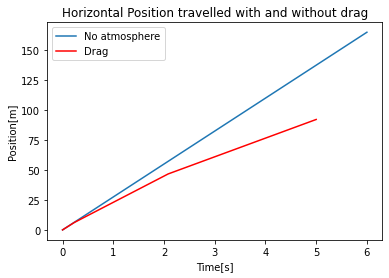

In [20]:
plt.plot(sol.t,sol.y[0,:],label="No atmosphere")
plt.plot(solD.t,solD.y[0,:],'r',label="Drag")
plt.title("Horizontal Position travelled with and without drag")
plt.xlabel("Time[s]")
plt.ylabel("Position[m]")
plt.legend()
plt.show()

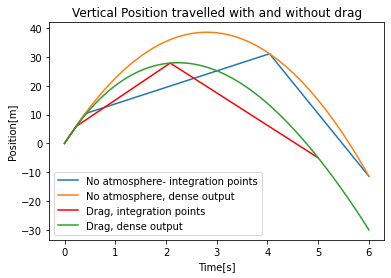

In [21]:
plt.plot(sol.t,sol.y[2,:],label="No atmosphere- integration points")
plt.plot(tlist,sol.sol(tlist)[2],label="No atmosphere, dense output")
plt.plot(solD.t,solD.y[2,:],'r',label="Drag, integration points")
plt.plot(tlist,solD.sol(tlist)[2],label="Drag, dense output")
plt.title("Vertical Position travelled with and without drag")
plt.xlabel("Time[s]")
plt.ylabel("Position[m]")
plt.legend()
plt.show()

In [22]:
#now solve for when the ball hits the ground in the two cases:
from scipy.optimize import root
t1=root(lambda t: sol.sol(t)[2],5)
print(t1)

 message: The solution converged.
 success: True
  status: 1
     fun: [-1.066e-14]
       x: [ 5.612e+00]
  method: hybr
    nfev: 8
    fjac: [[-1.000e+00]]
       r: [ 2.750e+01]
     qtf: [-2.134e-10]


In [23]:
tDrag=root(lambda t: solD.sol(t)[2],5)
print(tDrag)

 message: The solution converged.
 success: True
  status: 1
     fun: [ 1.066e-14]
       x: [ 4.766e+00]
  method: hybr
    nfev: 7
    fjac: [[-1.000e+00]]
       r: [ 2.067e+01]
     qtf: [ 2.413e-10]


In [24]:
time0=t1.x[0]
timeDrag=tDrag.x[0]
np.set_printoptions(precision=1,suppress=True)
print(f'The time of flight without air is {time0:5.4} s and with drag is {timeDrag:5.4} s.')
print(f'The position the ball lands without air is {sol.sol(time0)[0:3]} versus {solD.sol(timeDrag)[0:3]} m with drag')
print('\n\n')
#find original and final velocity and energy
v0=solD.sol(0)[3:6]
vF=solD.sol(timeDrag)[3:6]
EF=solD.sol(timeDrag)[6]
startingKinetic=0.5*mass*np.dot(v0,v0)
endingKinetic=0.5*mass*np.dot(vF,vF)
print(f'''The initial and final kinetic energies are {startingKinetic:5.3}, {endingKinetic:5.3} J, 
      with work done against drag as {EF:5.3}\n\n\n\n''')

print(f'The energy sum (initial-final) is {startingKinetic+EF-endingKinetic:12.10}')

The time of flight without air is 5.612 s and with drag is 4.766 s.
The position the ball lands without air is [154.3   0.   -0. ] versus [89.2  0.   0. ] m with drag



The initial and final kinetic energies are 1.1e+02,  43.1 J, 
      with work done against drag as -66.6




The energy sum (initial-final) is 0.001283642963


This is ok, but not wonderful.  Is the difference in energy due to a small mistake or because of numerics? We check by putting a stricter tolerance on the solver.

In [26]:
sol=solve_ivp(dxvdt,(0,6),np.array([0,0,0,1/np.sqrt(2.0),0,1/np.sqrt(2)])*1.4e5/3600.,method='DOP853',dense_output=True,rtol=1e-11)
solD=solve_ivp(dxvdtD,(0,5),np.array([0,0,0,1.0/np.sqrt(2.),0,1/np.sqrt(2),0])*1.4e5/3600.,method='DOP853',dense_output=True,rtol=1e-11)
tDrag=root(lambda t: solD.sol(t)[2],5)
time0=t1.x[0]
timeDrag=tDrag.x[0]
np.set_printoptions(precision=1,suppress=True)
print(f'The time of flight without air is {time0:5.4} s and with drag is {timeDrag:5.4} s.')
print(f'The position the ball lands without air is {sol.sol(time0)[0:3]} versus {solD.sol(timeDrag)[0:3]} m with drag')
print('\n\n')
#find original and final velocity and energy
v0=solD.sol(0)[3:6]
vF=solD.sol(timeDrag)[3:6]
EF=solD.sol(timeDrag)[6]
startingKinetic=0.5*mass*np.dot(v0,v0)
endingKinetic=0.5*mass*np.dot(vF,vF)
print(f'''The initial and final kinetic energies are {startingKinetic:5.3}, {endingKinetic:5.3} J, 
      with work done against drag as {EF:5.3}\n\n\n\n''')

print(f'The energy sum (initial-final) is {startingKinetic+EF-endingKinetic:12.10}')

The time of flight without air is 5.612 s and with drag is 4.766 s.
The position the ball lands without air is [154.3   0.   -0. ] versus [89.2  0.  -0. ] m with drag



The initial and final kinetic energies are 1.1e+02,  43.1 J, 
      with work done against drag as -66.6




The energy sum (initial-final) is -1.23578765e-07


This answers the question.  But for fun we can plot the range as a function of angle, and find the maximum range,

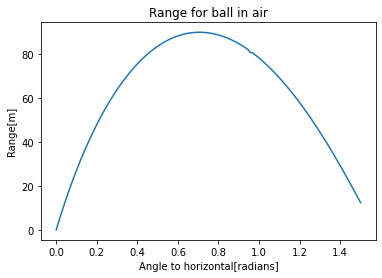

The rough maximum (just based on the list of values) range is  90.1 m, at an angle of  40.4 degrees


In [28]:
def range(theta):
    solD=solve_ivp(dxvdtD,(0,5),np.array([0,0,0,np.cos(theta),0,np.sin(theta),0])*1.4e5/3600.,method='DOP853',dense_output=True,rtol=1e-11)
    t=root(lambda t: solD.sol(t)[2],5).x[0]
    return np.linalg.norm(solD.sol(t)[0:3])

thlist=np.linspace(0,1.5,150)
rlist=np.array([range(th) for th in thlist])
plt.plot(thlist,rlist)
plt.title("Range for ball in air")
plt.xlabel("Angle to horizontal[radians]")
plt.ylabel("Range[m]")
plt.show()

print(f'The rough maximum (just based on the list of values) range is {np.max(rlist):5.1f} m, at an angle of {180/np.pi*thlist[np.argmax(rlist)]:5.3} degrees')